In [4]:
import os
import torch
import scipy.io as sio
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import polars as pl

In [2]:
def load_mat(filename):
    sample = sio.loadmat(filename)
    proc = lambda arr : torch.from_numpy(np.atleast_3d(arr).transpose((2, 0, 1)))
    sample = {k: proc(v) for k,v in sample.items() if k[:2] != '__'}
    # Key name changes
    sample['est'] = sample['normals_prior']
    sample['image'] = sample['images']
    sample['label'] = sample['normals_gt']
    return sample


def load_pth(filename):
    return torch.load(filename)


def normalize_normals(normals):
    normalsn = normals - torch.min(normals)
    normalsm = normalsn / (torch.max(normalsn) + 1e-8)
    return normalsm

In [ ]:
def _viz_polar_images(images, axes=None):
    # Plot polar images
    if axes is None:
        _, ax_arr = plt.subplots(2, 2)
        axes = [ax_arr[i // 2][i % 2] for i in range(4)]
    angles = [0, 45, 90, 135]
    for i in range(len(images)):
        img, ax = images[i], axes[i]
        ax.imshow(img)
        ax.set_title(f"Polar Image @ {angles[i]}°")


def _viz_mask(mask, ax=None):
    # Plot Binary Mask
    if ax is None:
        _, ax = plt.subplots(1, 1)
    ax.imshow(mask[0])
    ax.set_title("Binary Foreground Mask")


def _viz_normals_gt(normals, ax=None):
    # Plot normal GT
    if ax is None:
        _, ax = plt.subplots(1, 1)
    ax.imshow(normalize_normals(normals).permute(1, 2, 0))
    ax.set_title("Normals GT")


def _viz_normals_prior(normals, axes=None):
    # Plot normal priors
    if axes is None:
        _, axes = plt.subplots(1, 3)
    solution_type = ["Diffuse", "Specular 1", "Specular 2"]
    for i in range(len(normals) // 3):
        normal, ax = normals[(3 * i) : (3 * i) + 3], axes[i]
        ax.imshow(normalize_normals(normal).permute(1, 2, 0))
        ax.set_title(f"Normals Prior:\n{solution_type[i]} Solution")


def visualize_data(
    sample, sample_name=None, figsize=(12, 12), disp=False, dest_dir=None, logger=None
):
    # Setup
    fig = plt.figure(constrained_layout=True, figsize=figsize)
    fig.tight_layout()
    if sample_name is not None:
        fig.suptitle(f"{sample_name}", y=1.01)
    gs = GridSpec(3, 3, figure=fig)

    # Polar images
    polar_image_axes = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(4)]
    _viz_polar_images(sample["image"], axes=polar_image_axes)

    # Binary Mask
    binary_mask_ax = fig.add_subplot(gs[0, 2])
    _viz_mask(sample["mask"], ax=binary_mask_ax)

    # Normals GT
    normals_gt_ax = fig.add_subplot(gs[1, 2])
    _viz_normals_gt(sample["label"], ax=normals_gt_ax)

    # Normals Priors
    normals_prior_axes = [fig.add_subplot(gs[2, i]) for i in range(3)]
    _viz_normals_prior(sample["est"], axes=normals_prior_axes)

    # Display / Saving / Cleanup
    if disp:
        plt.show()
    if dest_dir is not None:
        dest = os.path.join(dest_dir, f"{sample_name.replace('/', '-')}.png")
        if logger is not None:
            logger.info(f"\tSaving data viz to {os.path.realpath(dest)}")
        fig.savefig(dest, facecolor="w")
    plt.close()

In [5]:
ROOT_DIR = '../DeepSfP/data/SurfaceNormals'

df = pl.read_csv(
    source=os.path.join(ROOT_DIR, 'train_list.csv'),
    has_header=False
).rename(
    mapping={
        'column_1': 'file_name'
        }
    )
print(df.shape, df.columns)
df.show()

(236, 1) ['file_name']


file_name
str
"""indoor/bird1_b.mat"""
"""indoor/bird1_f.mat"""
"""indoor/bird1_l.mat"""
"""indoor/bird1_r.mat"""
"""indoor/bird2_b.mat"""


In [6]:
PRECISION = np.float32

def to_tensor(arr, mask, precision=None):
    """
    Convert to Cx1024x1024 tensors consumable by model
    """
    arr = np.atleast_3d(arr)  # expand to 3d
    arr = arr * np.atleast_3d(mask)  # apply binary mask
    arr = arr[:, 100: 1124, :]  # remove padding
    arr = arr.transpose((2, 0, 1))  # transpose to CxHxW
    if not precision:
        precision = PRECISION
    arr = arr.astype(precision)  # convert precision
    arr = torch.from_numpy(arr)  # convert to tensor
    return arr

In [8]:
i = 123
file_path = os.path.join(ROOT_DIR, 'objects', df.item(i, 'file_name'))

mat_file = sio.loadmat(file_path)
mask = mat_file["mask"]
sample = {
    "image": to_tensor(mat_file["images"], mask),
    "est": to_tensor(mat_file["normals_prior"], mask),
    "label": to_tensor(mat_file["normals_gt"], mask),
    "mask": to_tensor(
        np.stack((mask, mask, mask), axis=2), mask, "uint8"
    ),
}
print(i, os.path.isfile(file_path))
# print(sample)

123 True


/tmp/ipykernel_1024812/2812140546.py:45: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


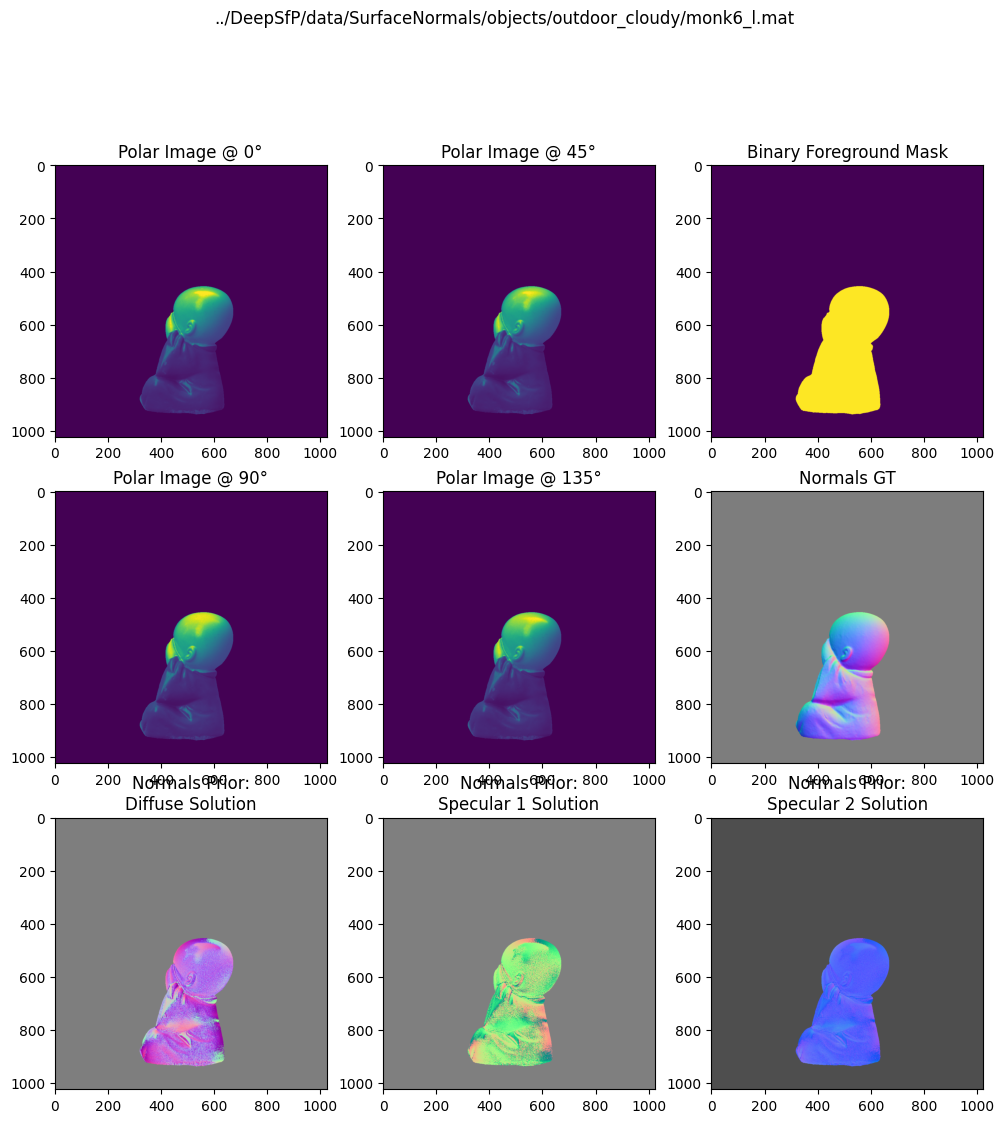

In [9]:
FIGSIZE=(12, 12)
DISP=True
SAVE=True

PHASE = 'test'  # 'train' or 'test'
PTH_FILES = False  # Whether to visualize transformed data (i.e. converted from .mat to .pth, 
                   # see https://github.com/alexrgilbert/deepsfp/blob/master/README.md)



visualize_data(sample, sample_name=file_path, figsize=FIGSIZE, disp=DISP, dest_dir="", logger=None)